In [2]:
import numpy as np
import pandas as pd
import random
from chemevo import evolution_V1 as evo

import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import matplotlib.cm as cm
import matplotlib.lines as mlines
import itertools
import random

params = {
   'axes.labelsize': 20,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 20,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

In [58]:
import glob

# 1. Load the fitted data lines
summary_df = pd.read_csv("data_fitted_line_in_bins_of_mg_h.csv")

# Round the bin centers to avoid floating-point merge errors (e.g., -0.5 vs -0.50000001)
summary_df['mg_h_bin_round'] = summary_df['mg_h_bin_center'].round(3)

# 2. Get all saved model files
model_files = glob.glob("models/alpha_cc_*.csv")
chi2_results = []

for file in model_files:
    model_df = pd.read_csv(file)
    
    # Round model bins to match
    model_df['mg_h_bin_round'] = model_df['mg_h_bin'].round(3)
    
    # Merge the model galaxies with the corresponding data line for their bin
    merged_df = pd.merge(
        model_df,
        summary_df,
        on='mg_h_bin_round',
        how='inner'
    )
    
    # Drop rows where the data bin didn't have enough points to fit a line (NaN slopes)
    merged_df = merged_df.dropna(subset=['slope_mn_fe', 'intercept_mn_fe'])
    
    if len(merged_df) == 0:
        continue

    # 3. Calculate Expected Y (Mn/Fe) from the data line
    expected_mn_fe = (merged_df['slope_mn_fe'] * merged_df['fe_mg']) + merged_df['intercept_mn_fe']
    
    # 4. Calculate Chi-Square (Sum of Squared Residuals)
    residuals_sq = (merged_df['mn_fe'] - expected_mn_fe)**2
    chi2_total = residuals_sq.sum()
    n_points = len(residuals_sq)
    
    # Calculate reduced Chi-Square (normalizes by the number of points)
    reduced_chi2 = chi2_total / n_points 

    # Save the results for this global parameter file
    chi2_results.append({
        'file': file,
        'alpha_cc': merged_df['alpha_cc'].iloc[0], # Grab the global parameter
        'alpha_Ia': merged_df['alpha_Ia'].iloc[0], # Grab the global parameter
        'gcc': merged_df['gcc'].iloc[0], # Grab the global parameter
        'gIa/gcc': merged_df['gIa/gcc'].iloc[0], # Grab the global parameter
        'Upsilon': merged_df['Upsilon'].iloc[0], # Grab the global parameter
        'chi2_total': chi2_total,
        'reduced_chi2': reduced_chi2,
        'n_points': n_points
    })

# 5. Convert to DataFrame and find the best fit
results_df = pd.DataFrame(chi2_results)

# Sort by lowest reduced chi2
results_df = results_df.sort_values(by='reduced_chi2').reset_index(drop=True)

print("Top 3 Best Fitting Global Models:")
print(results_df.head(3))

# Isolate the absolute best
best_model = results_df.iloc[0]
print(f"\nThe best fit is {best_model['file']} with alpha_cc = {best_model['alpha_cc']}, alpha_Ia = {best_model['alpha_Ia']}, gcc = {best_model['gcc']}, gIa/gcc = {best_model['gIa/gcc']}, Upsilon = {best_model['Upsilon']}")

Top 3 Best Fitting Global Models:
                     file  alpha_cc  alpha_Ia  gcc  gIa/gcc  Upsilon  \
0  models/alpha_cc_11.csv      0.55       0.3  0.4        2        1   
1  models/alpha_cc_10.csv      0.50       0.3  0.4        2        1   
2  models/alpha_cc_12.csv      0.60       0.3  0.4        2        1   

   chi2_total  reduced_chi2  n_points  
0    4.023185      0.002689      1496  
1    4.352624      0.002910      1496  
2    4.410451      0.002948      1496  

The best fit is models/alpha_cc_11.csv with alpha_cc = 0.55, alpha_Ia = 0.3, gcc = 0.4, gIa/gcc = 2, Upsilon = 1


In [8]:
summary_df

,Unnamed: 0,mg_h_bin_center,slope_mn_fe,intercept_mn_fe,slope_mn_mg,intercept_mn_mg,mg_h_bin_round
0,0,-6.000000e-01,0.566777,-0.104276,1.566777,-0.104276,-0.6
1,1,-4.000000e-01,0.456078,-0.081490,1.456078,-0.081490,-0.4
2,2,-2.000000e-01,0.369447,-0.060267,1.369447,-0.060267,-0.2
3,3,8.326673e-17,0.415651,-0.006514,1.415651,-0.006514,0.0
4,4,2.000000e-01,0.646670,0.071568,1.646670,0.071568,0.2


In [ ]:
# 1. Define bin edges
fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)

# 2. Read and combine all files
dfs = []
for i in range(21):
    try:
        dfs.append(pd.read_csv(f'models/alpha_cc_{i}.csv'))
    except FileNotFoundError:
        continue # Skips if a file is missing

df_all = pd.concat(dfs, ignore_index=True)

# 3. Create the fe/mg bins
df_all['fe_mg_bin'] = pd.cut(df_all['fe_mg'], bins=fe_mg_bin_edges)

# 4. Calculate median mn/fe per alpha_cc model and fe/mg bin, saving it as a new column
df_all['mn_fe_bin_median'] = df_all.groupby(['alpha_cc', 'fe_mg_bin'])['mn_fe'].transform('median')

# (Optional) If you just want a summary dataframe instead of the full dataframe:
df_summary = df_all.groupby(['alpha_cc', 'fe_mg_bin'])['mn_fe'].median().reset_index()df_summary.rename(columns={'mn_fe': 'median_mn_fe'}, inplace=True)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_64236/2388846498.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_all['mn_fe_bin_median'] = df_all.groupby(['alpha_cc', 'fe_mg_bin'])['mn_fe'].transform('median')
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_64236/2388846498.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_summary = df_all.groupby(['alpha_cc', 'fe_mg_bin'])['mn_fe'].median().reset_index()


In [16]:
summary_df

,Unnamed: 0,mg_h_bin_center,slope_mn_fe,intercept_mn_fe,slope_mn_mg,intercept_mn_mg,mg_h_bin_round
0,0,-6.000000e-01,0.566777,-0.104276,1.566777,-0.104276,-0.6
1,1,-4.000000e-01,0.456078,-0.081490,1.456078,-0.081490,-0.4
2,2,-2.000000e-01,0.369447,-0.060267,1.369447,-0.060267,-0.2
3,3,8.326673e-17,0.415651,-0.006514,1.415651,-0.006514,0.0
4,4,2.000000e-01,0.646670,0.071568,1.646670,0.071568,0.2


In [21]:
df_all['mg_h_bin']

0       -0.6
1       -0.6
2       -0.6
3       -0.6
4       -0.6
        ... 
31411    0.2
31412    0.2
31413    0.2
31414    0.2
31415    0.2
Name: mg_h_bin, Length: 31416, dtype: float64

In [19]:
df_all['mn_fe_bin_median']

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
31411         NaN
31412    0.034886
31413    0.034886
31414    0.034886
31415    0.034886
Name: mn_fe_bin_median, Length: 31416, dtype: float64

In [20]:
df_all['fe_mg_bin']

0                  NaN
1                  NaN
2                  NaN
3                  NaN
4                  NaN
             ...      
31411              NaN
31412    (-0.05, 0.05]
31413    (-0.05, 0.05]
31414    (-0.05, 0.05]
31415    (-0.05, 0.05]
Name: fe_mg_bin, Length: 31416, dtype: category
Categories (4, interval[float64, right]): [(-0.35, -0.25] < (-0.25, -0.15] < (-0.15, -0.05] < (-0.05, 0.05]]

In [23]:
alpha_cc_df = df_all

In [28]:
mg_h_bins = alpha_cc_df['mg_h_bin'].unique()

In [29]:
alpha_cc_df['alpha_cc'].unique()

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [33]:
alpha_cc_df

,mn_fe,mn_mg,fe_mg,fe_h,mg_h,mn_h,t,tau_star,eta,sfr,alpha_cc,alpha_Ia,gcc,gIa/gcc,Upsilon,mg_h_bin,fe_mg_bin,mn_fe_bin_median,fe_mg_center
0,0.063919,-0.385463,-0.449381,-1.047434,-0.598053,-0.983516,0.140239,0.500000,0.010000,const SFR,0.0,0.3,0.4,2,1,-0.6,NaN,NaN,NaN
1,0.063919,-0.385463,-0.449381,-1.041990,-0.592609,-0.978071,0.140239,0.500000,0.010000,exp SFR,0.0,0.3,0.4,2,1,-0.6,NaN,NaN,NaN
2,0.062099,-0.381038,-0.443137,-1.038050,-0.594912,-0.975950,0.294392,0.500000,0.010000,rise+fall 1,0.0,0.3,0.4,2,1,-0.6,NaN,NaN,NaN
3,0.061812,-0.380217,-0.442029,-1.026946,-0.584917,-0.965134,0.308406,0.500000,0.010000,rise+fall 2,0.0,0.3,0.4,2,1,-0.6,NaN,NaN,NaN
4,0.061811,-0.380210,-0.442021,-1.026538,-0.584517,-0.964727,0.308406,0.500000,0.010000,rise+fall 3,0.0,0.3,0.4,2,1,-0.6,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31411,0.132442,0.183767,0.051325,0.251406,0.200081,0.383848,11.043064,3.555556,0.464159,exp SFR,1.0,0.3,0.4,2,1,0.2,NaN,NaN,NaN
31412,0.107733,0.146742,0.039009,0.239062,0.200053,0.346795,10.398424,4.166667,0.464159,exp SFR,1.0,0.3,0.4,2,1,0.2,"(-0.05, 0.05]",0.034886,0.0
31413,0.088402,0.119560,0.031158,0.231218,0.200060,0.319620,10.230257,4.777778,0.464159,exp SFR,1.0,0.3,0.4,2,1,0.2,"(-0.05, 0.05]",0.034886,0.0
31414,0.072393,0.098157,0.025765,0.226072,0.200308,0.298465,10.244271,5.388889,0.464159,exp SFR,1.0,0.3,0.4,2,1,0.2,"(-0.05, 0.05]",0.034886,0.0


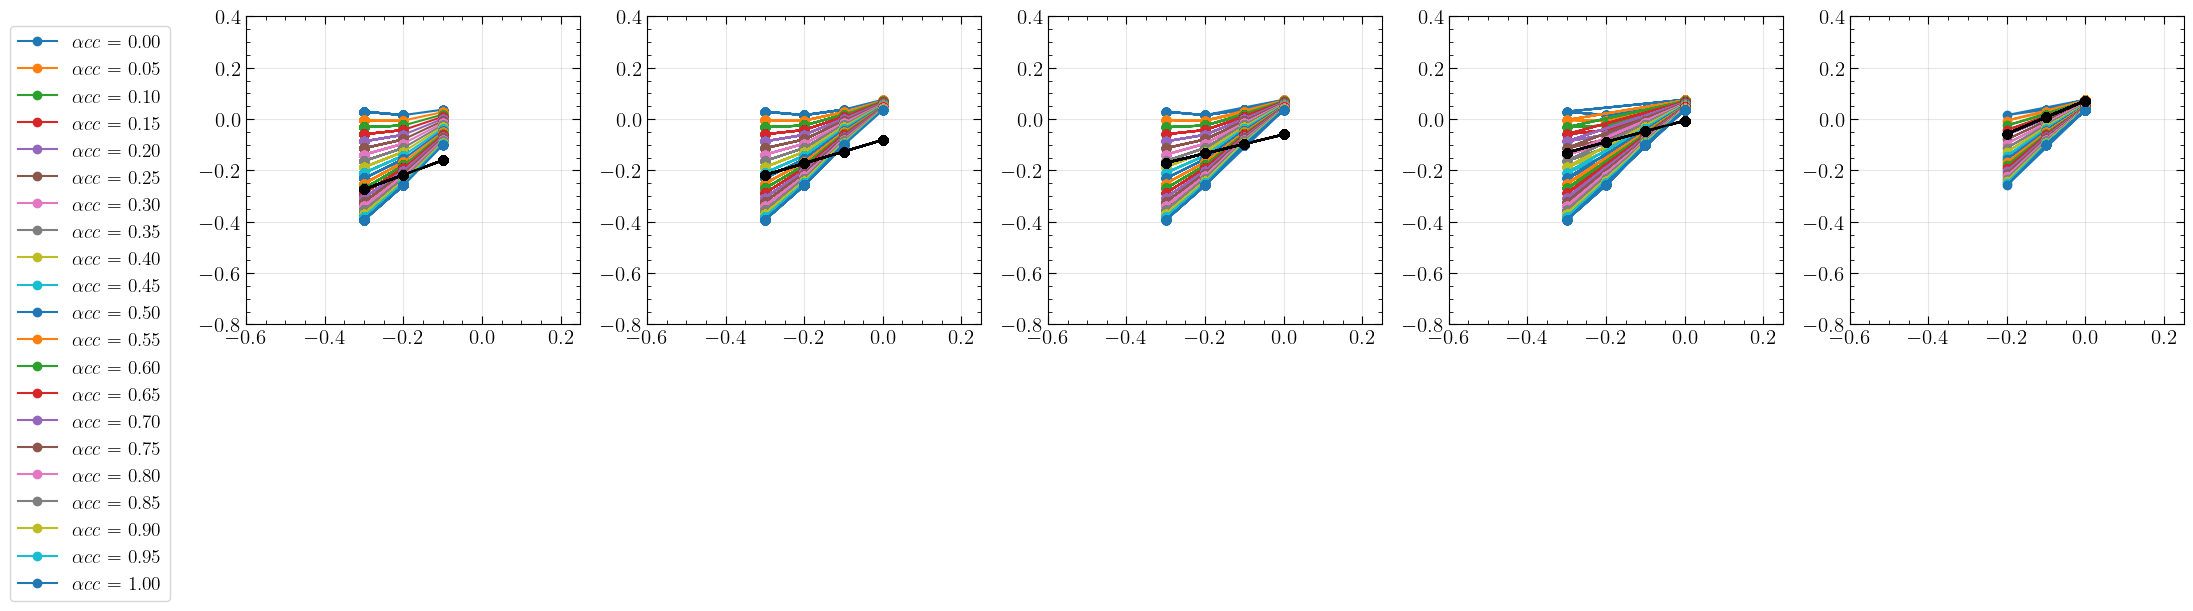

In [70]:
alpha_ccs = alpha_cc_df['alpha_cc'].unique()
plt.figure(figsize=(25,4))

fe_mg_data = np.linspace(min(fe_mg_bin_edges), max(fe_mg_bin_edges), 100)

for i in range(len(mg_h_bins)):
    plt.subplot(1,5,i+1)
    mg_h_df = alpha_cc_df[alpha_cc_df['mg_h_bin'] == mg_h_bins[i]]
    for j in range(len(alpha_ccs)):
        model = mg_h_df[mg_h_df['alpha_cc'] == alpha_ccs[j]]
        plt.plot(model['fe_mg_center'], model['mn_fe_bin_median'], marker='o', label = fr"$\alpha cc$ = {alpha_ccs[j]:.2f}")
        
        data_this_mg_h_bin = summary_df[summary_df['mg_h_bin_center'] == mg_h_bins[i]]
        #mn_fe_data = data_this_mg_h_bin['slope_mn_fe'].iloc[0] * fe_mg_data + data_this_mg_h_bin['intercept_mn_fe'].iloc[0]
        mn_fe_data = model['fe_mg_center'].astype(float) * data_this_mg_h_bin['slope_mn_fe'].iloc[0] + data_this_mg_h_bin['intercept_mn_fe'].iloc[0]

        #plt.plot(fe_mg_data, mn_fe_data)
        plt.plot(model['fe_mg_center'], mn_fe_data, marker='o', color = 'black')

    plt.grid(True, alpha = 0.3)
    plt.xlim(-0.60, 0.25)
    plt.ylim(-0.8, 0.40)
    if i == 0:
        plt.legend(bbox_to_anchor = [-0.2, 1])